In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [27]:
cell_num =1 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 1  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 1

## Step 0: Get loaded data 

In [28]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c1_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c1_patch.npy'


In [29]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

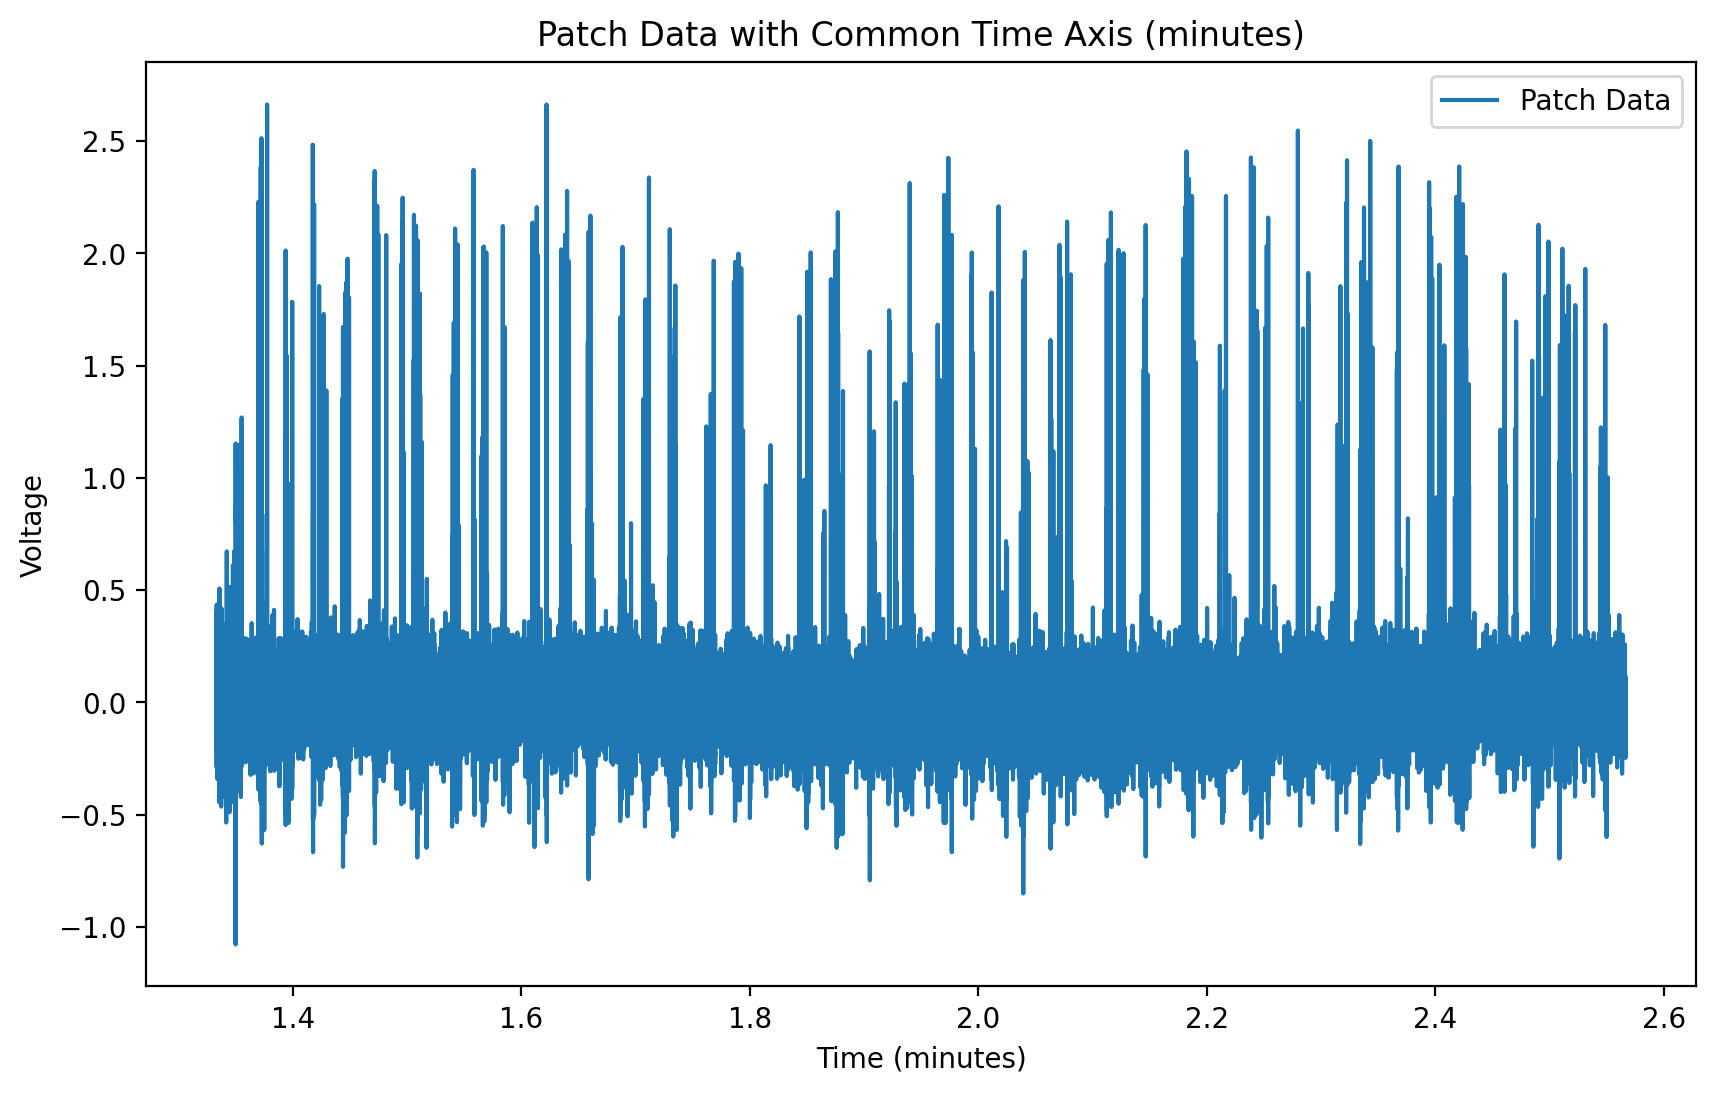

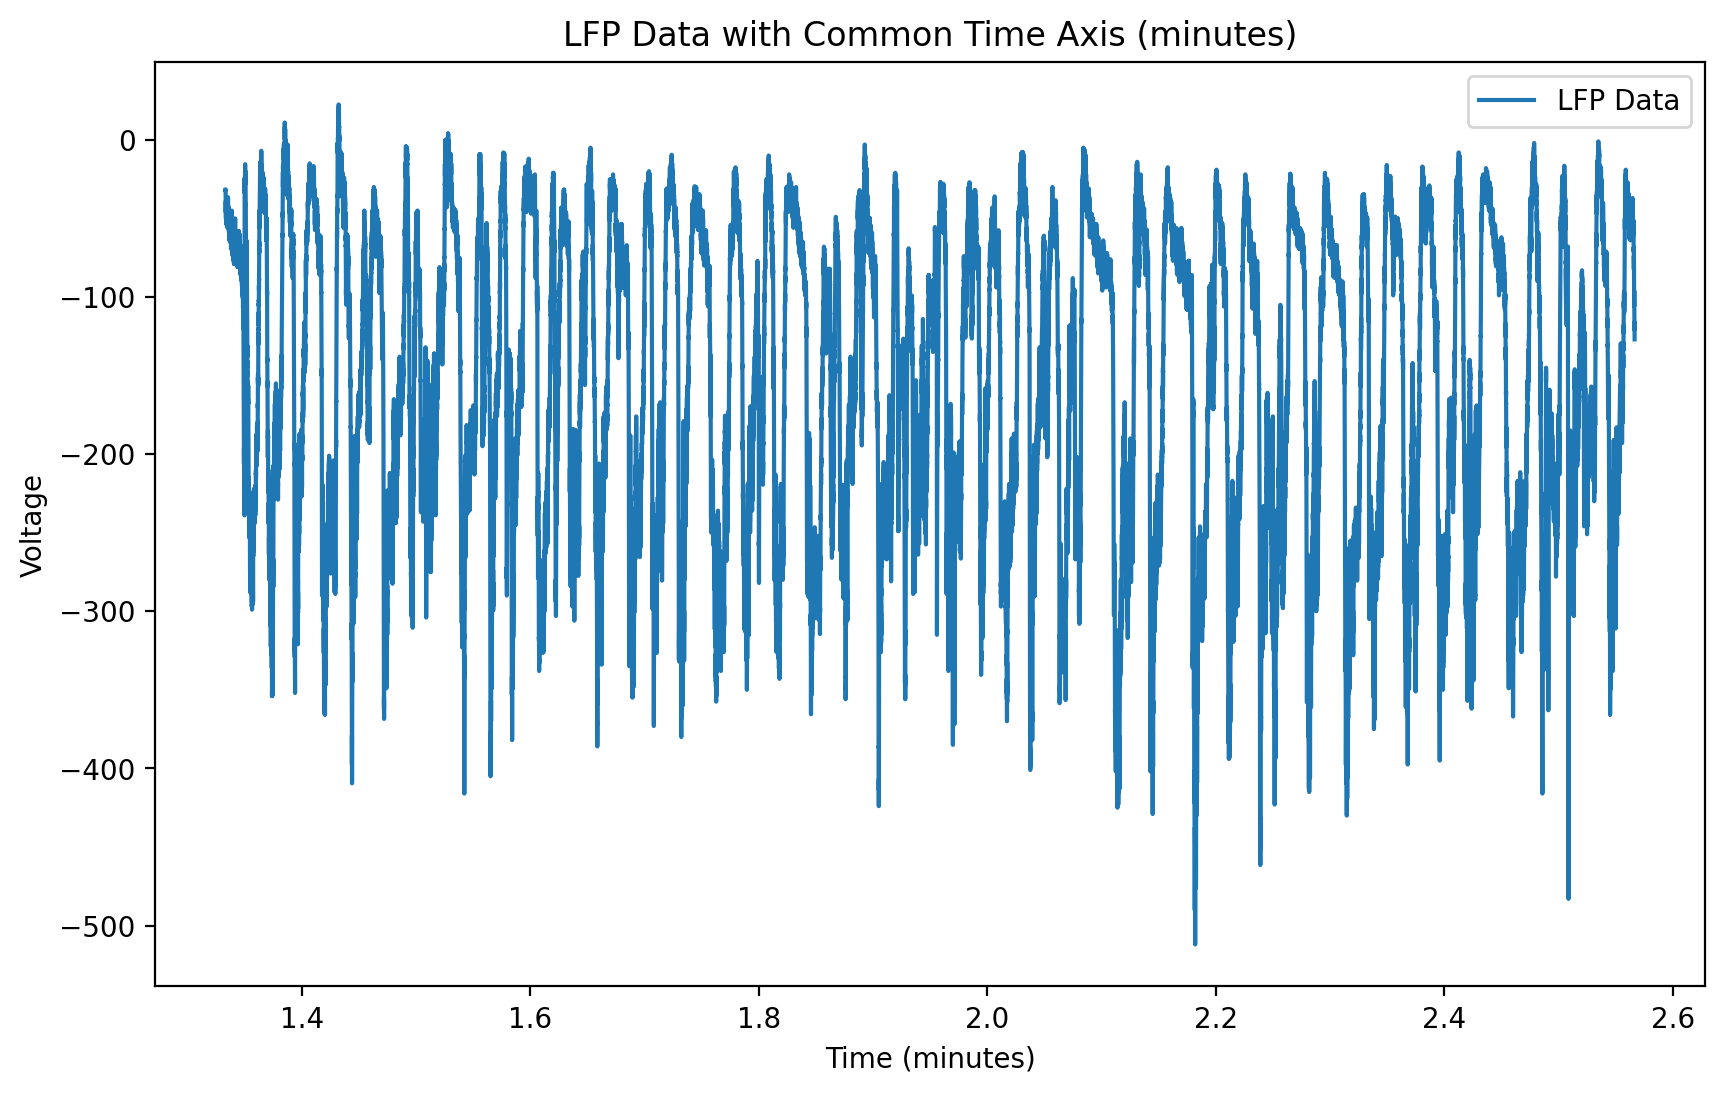

In [30]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

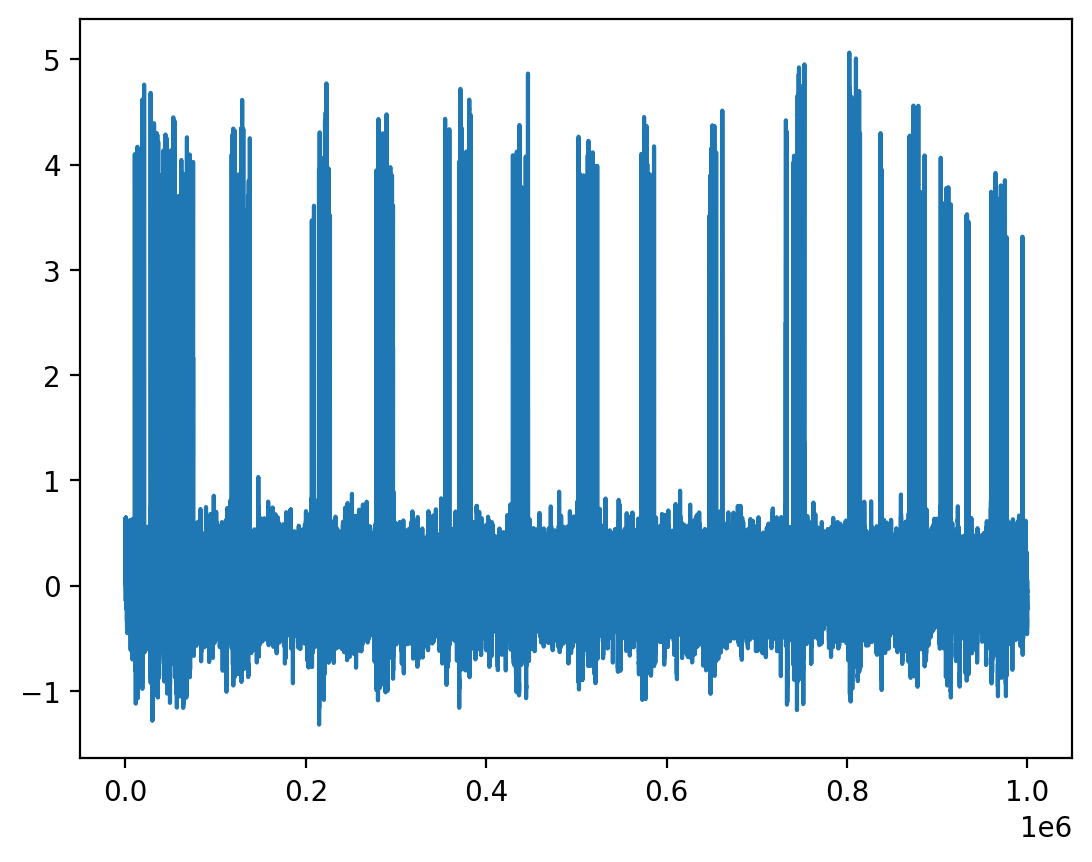

In [31]:
plt.plot(patch_filt[:1000000] )

In [32]:



#threshold in mVs
sp = Spike(thresh_amp=2, window_length=(5., 5.), smooth_frac=.01)

In [33]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=False)

Spike:   0%|          | 0/1121 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


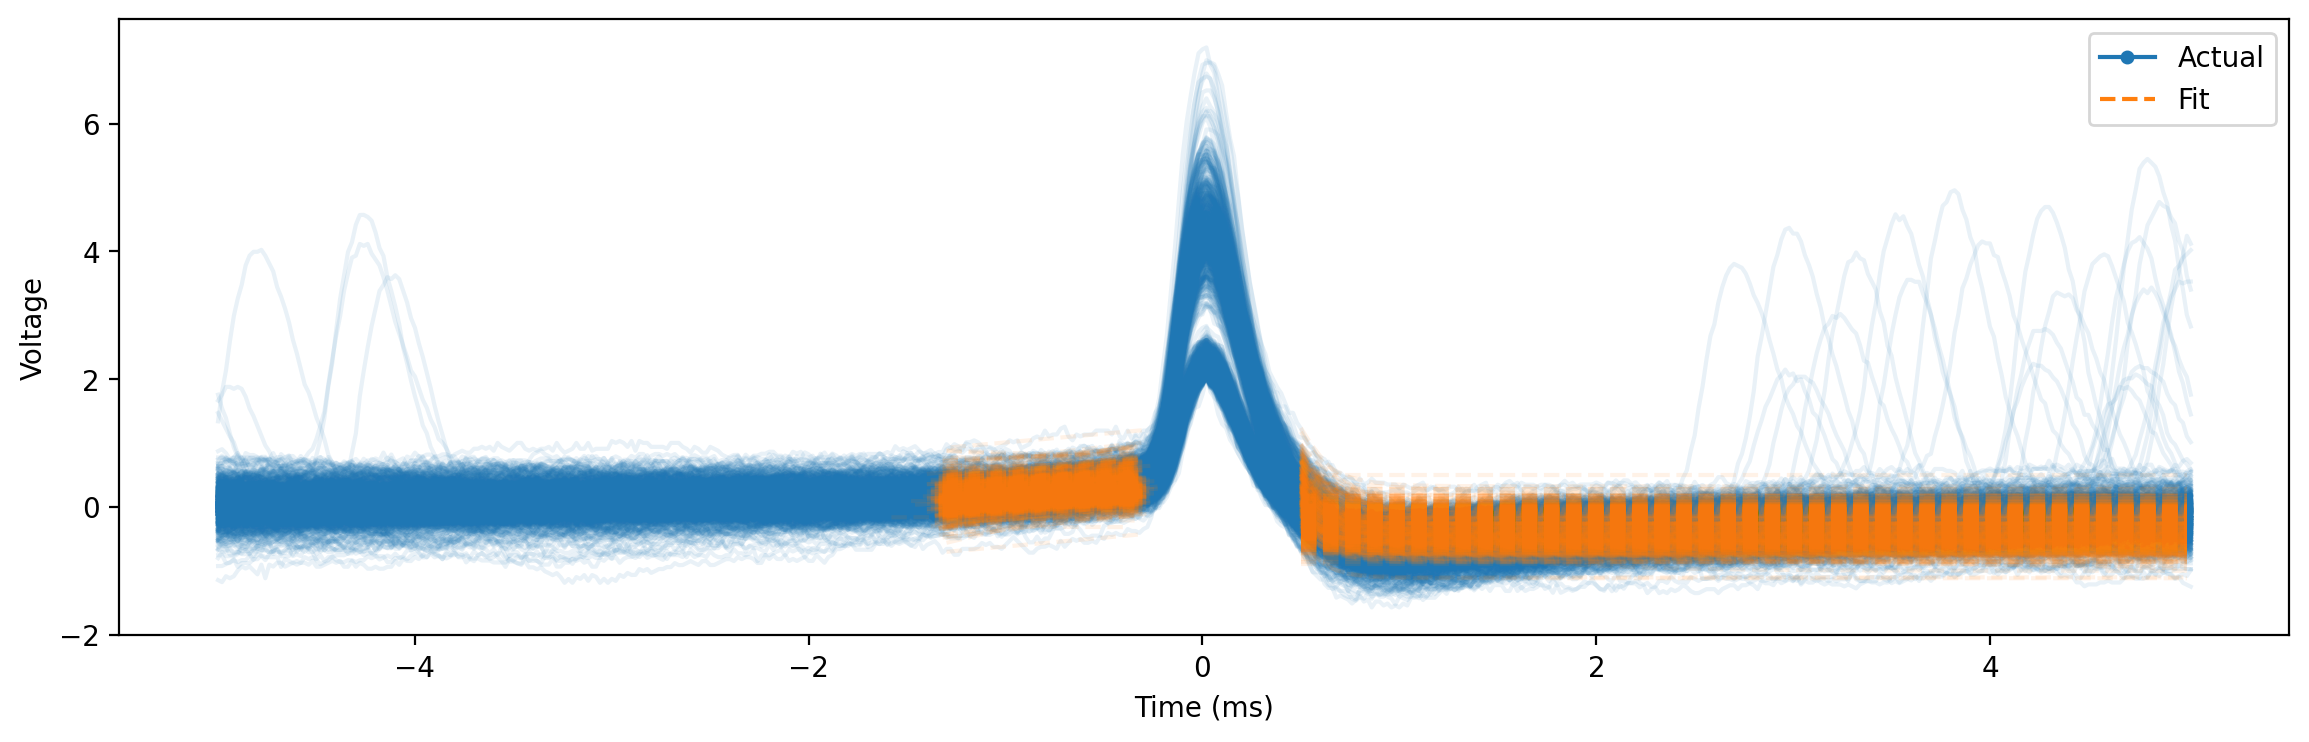

In [34]:
sp.plot()

### Filter spikes 

In [35]:
sp.filter_features()  

### Get spike dataframe (with spike times column)

In [36]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [37]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.009837,0.32,0.467007,4.066770,0.38,0.776966,1.030429,-0.350241,1.501946,10429,208.480268,0
1,0.047172,0.30,0.400746,4.000609,0.36,0.822552,3.802945,-0.521668,1.422054,12018,240.245073,1
2,-0.036794,0.34,0.292508,4.075305,0.36,0.623636,5.915424,-0.861539,2.034020,13340,266.672431,2
3,0.508333,0.32,0.288763,4.554854,0.38,0.882994,10.000000,-0.618316,1.597268,18750,374.820695,3
4,0.242062,0.32,0.671918,4.696013,0.36,0.867873,6.667226,-0.435759,2.159420,20729,414.381770,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1116,0.078585,0.30,0.326825,1.944270,0.32,0.381207,0.000018,-0.056124,3.809923,11392736,227745.772080,1114
1117,0.012062,0.26,0.512724,1.945625,0.26,0.412176,0.000022,-0.021553,3.639914,11715660,234201.163981,1115
1118,0.156769,0.30,0.425757,2.136809,0.32,0.399556,0.000017,0.129661,4.246379,11933979,238565.456212,1116
1119,0.148740,0.34,0.467079,2.022752,0.34,0.353169,0.016804,-1.369805,3.694783,12816157,256200.580007,1117


### Get spike times


In [38]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster spike groups 

Plotting spike features...
Removing outliers using IQR method (multiplier=3)


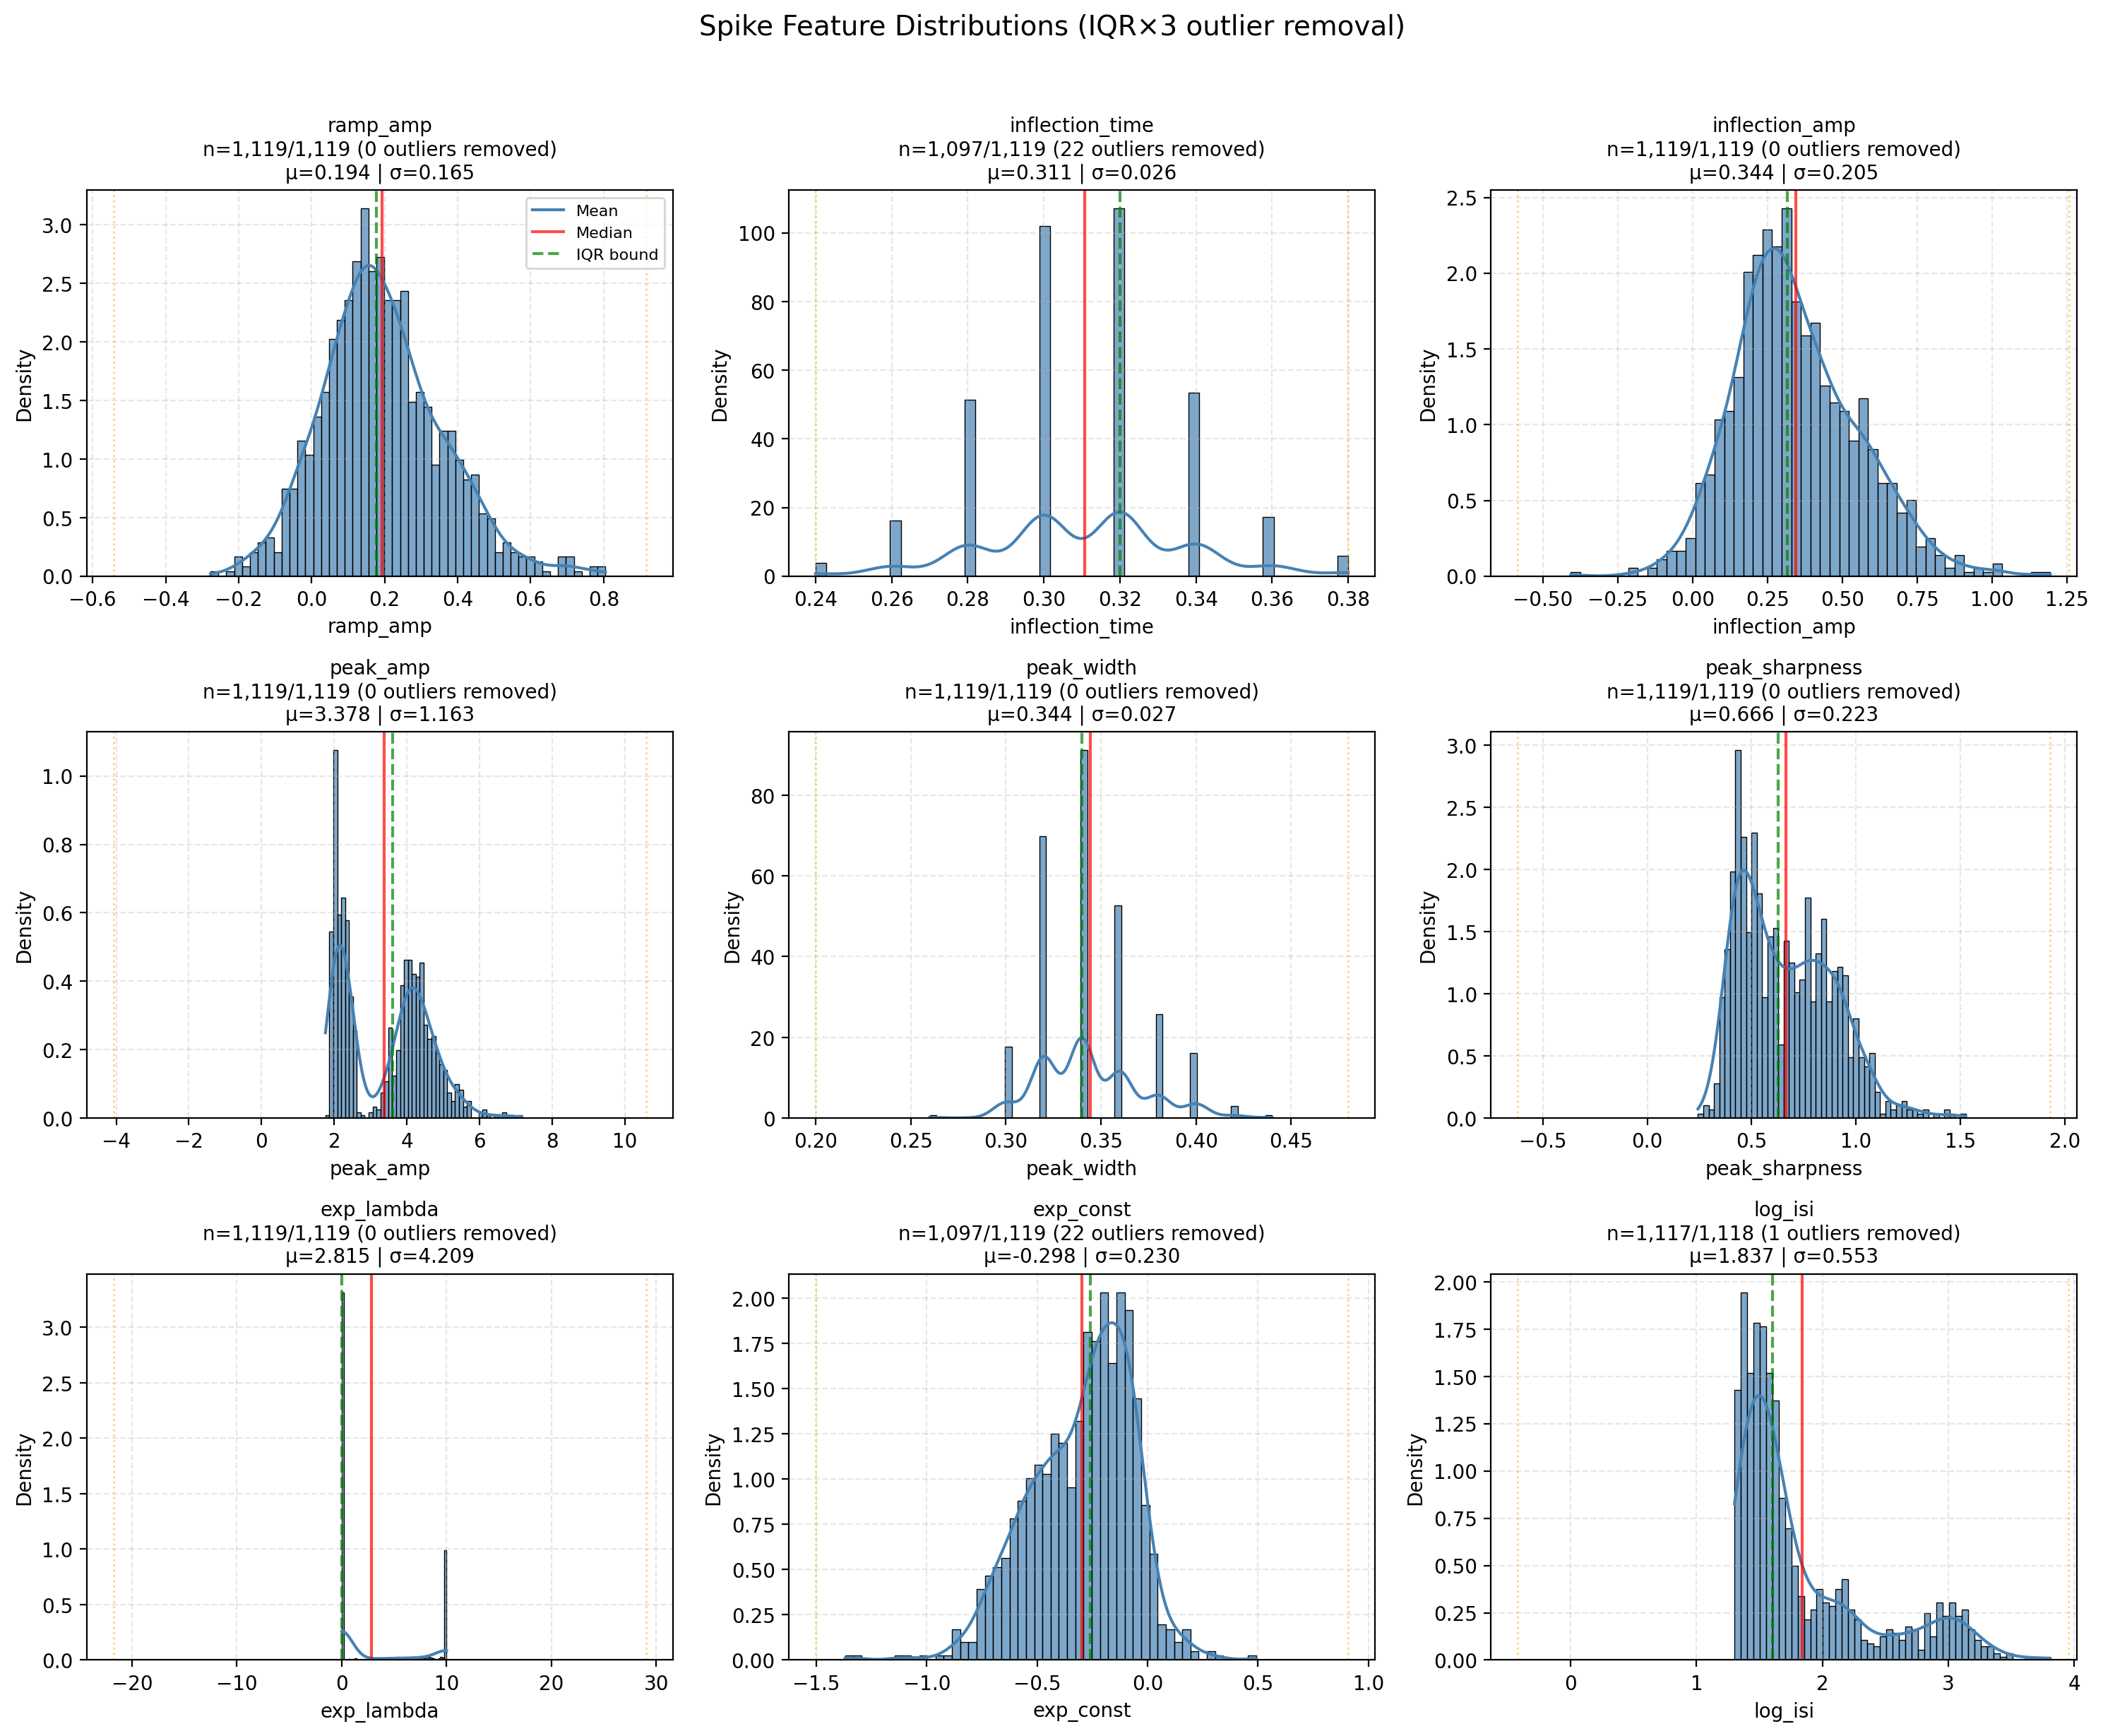


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             1119       1119       0          0.0        0.194      0.165     
inflection_time      1119       1097       22         2.0        0.311      0.026     
inflection_amp       1119       1119       0          0.0        0.344      0.205     
peak_amp             1119       1119       0          0.0        3.378      1.163     
peak_width           1119       1119       0          0.0        0.344      0.027     
peak_sharpness       1119       1119       0          0.0        0.666      0.223     
exp_lambda           1119       1119       0          0.0        2.815      4.209     
exp_const            1119       1097       22         2.0        -0.298     0.230     
log_isi              1118       1117       1          0.1        1.837      0.553     


In [39]:
plot_spike_feature_distributions(df_features)

ramp_amp: Skipped - k_suggest = 1
→ inflection_time: Skipping (feature ignored).
inflection_amp: Skipped - k_suggest = 1


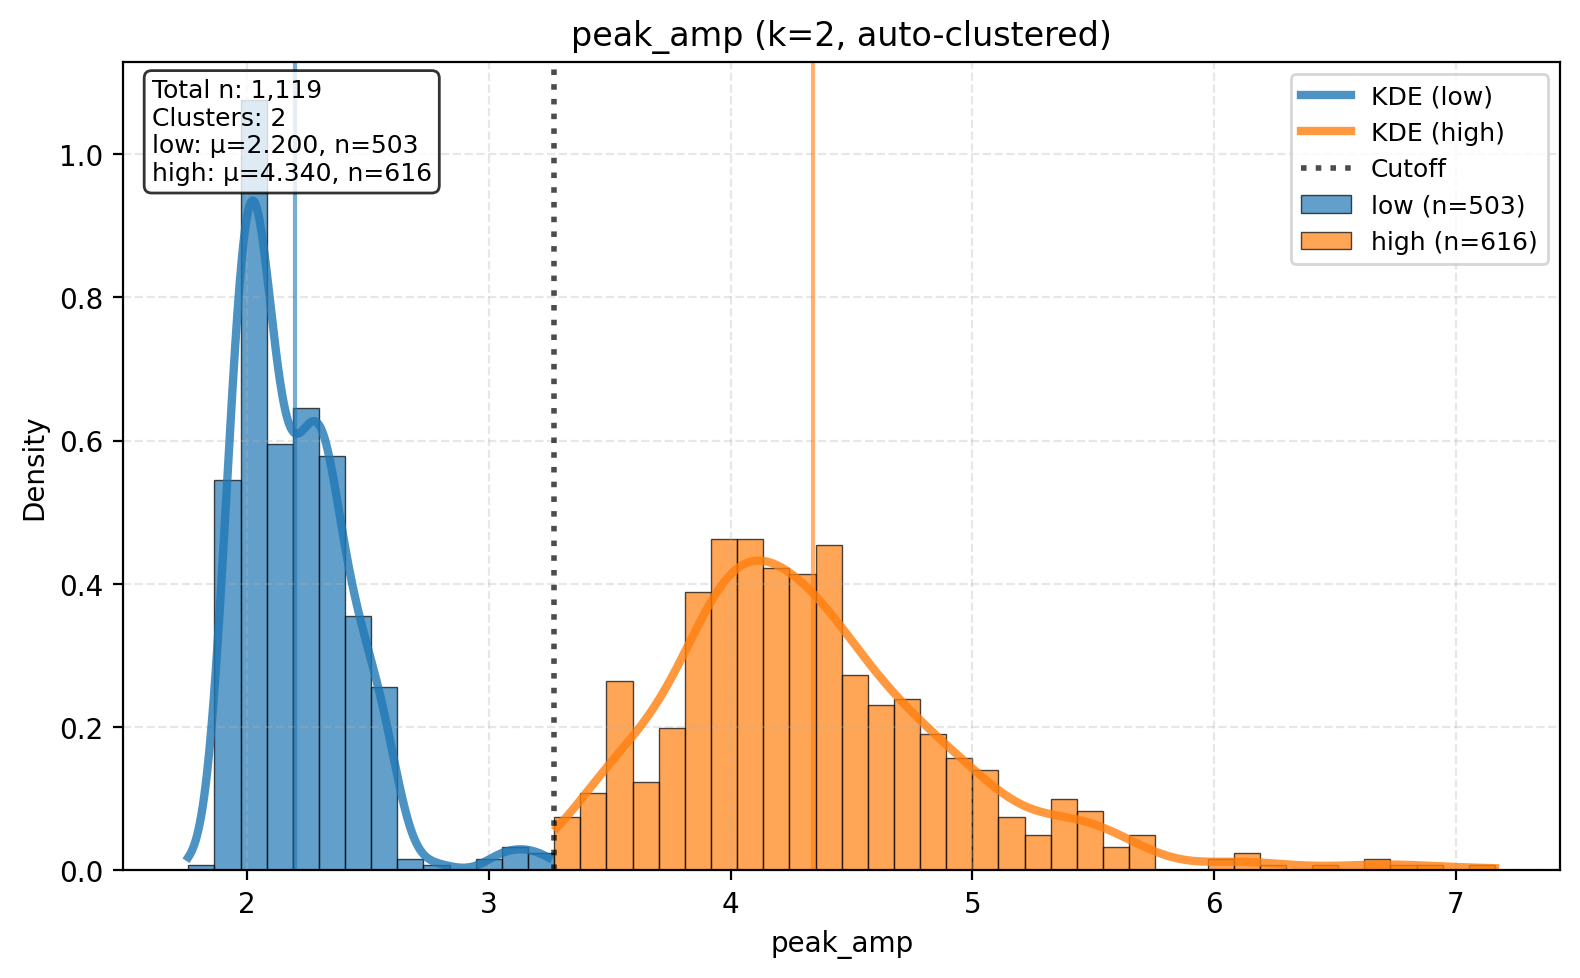

peak_width: Skipped - k_suggest = 1


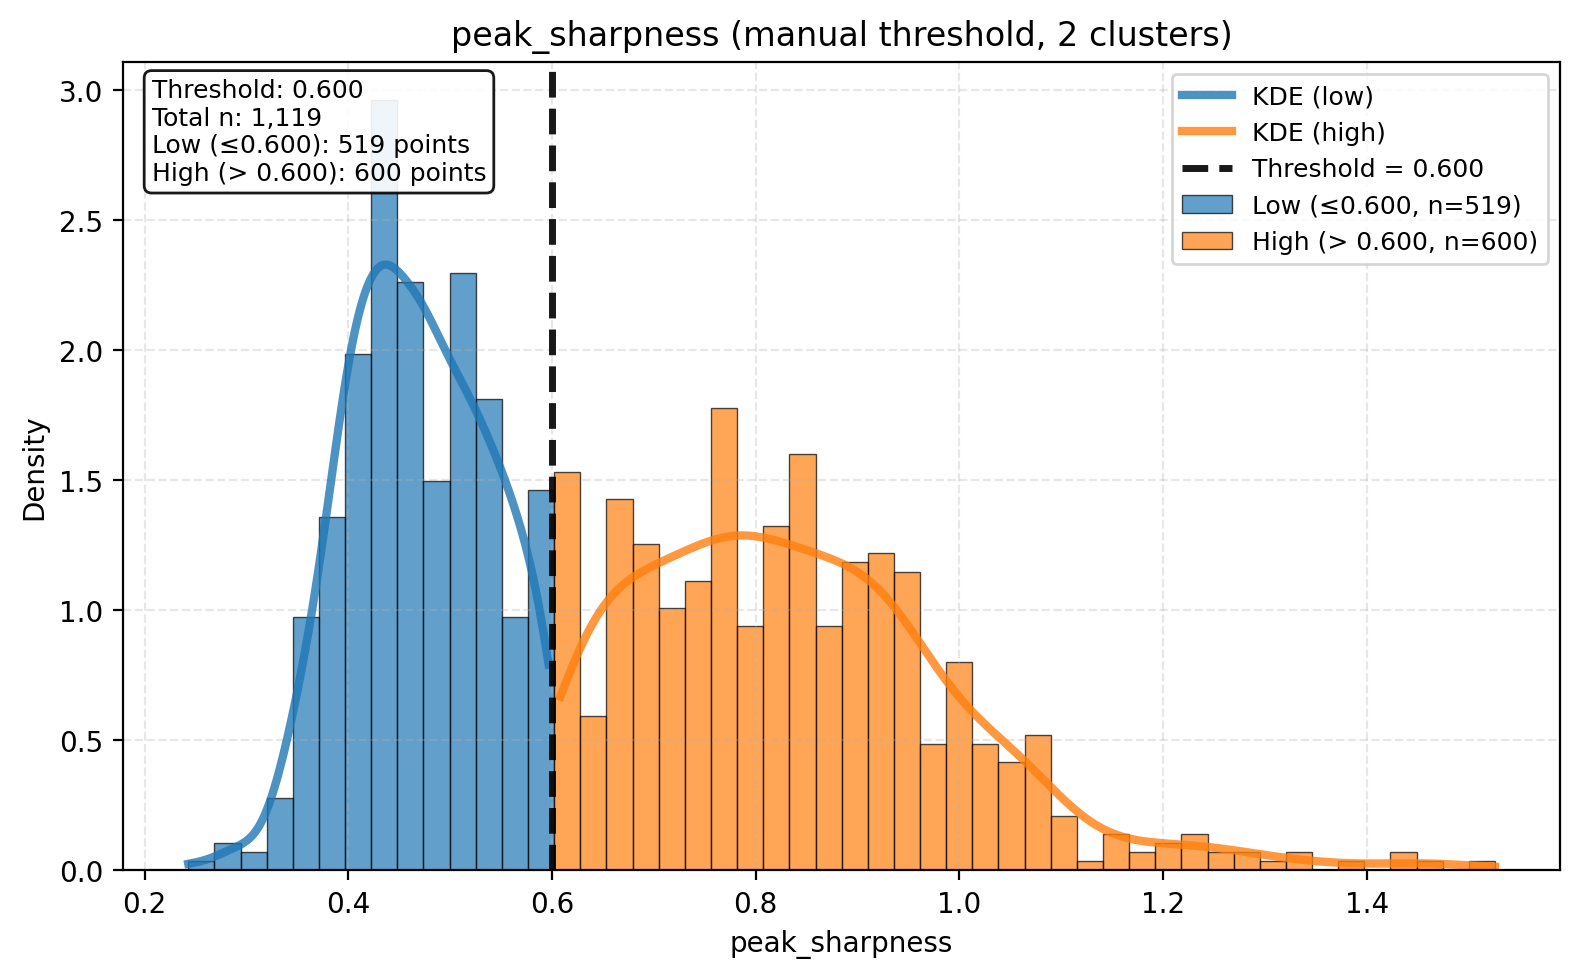

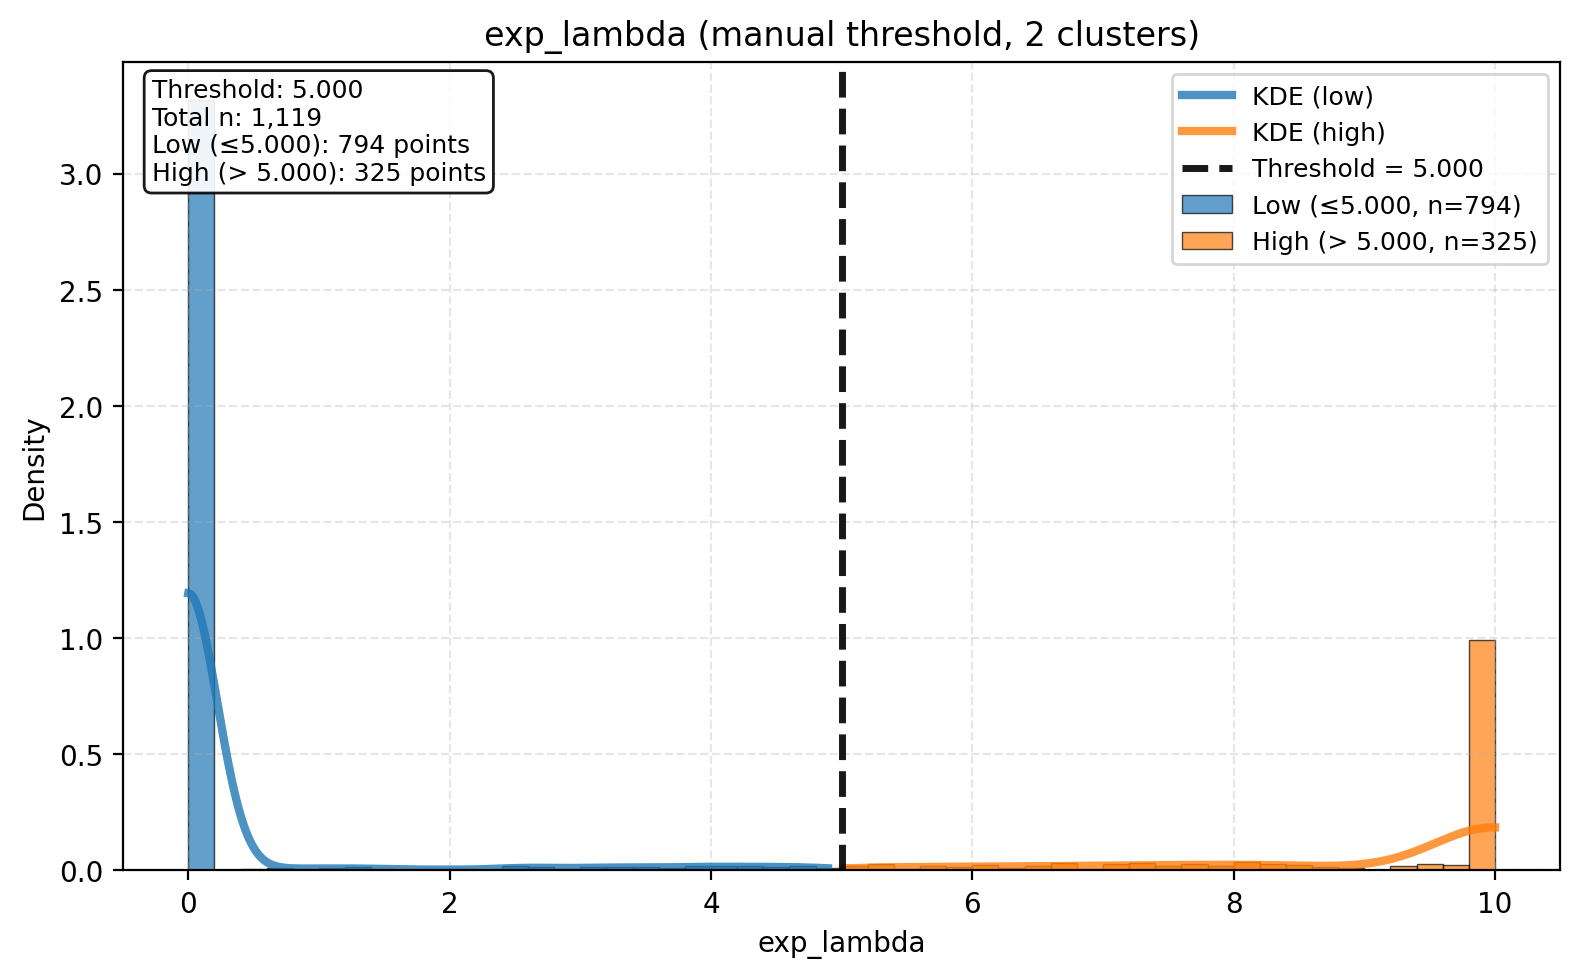

exp_const: Skipped - k_suggest = 1


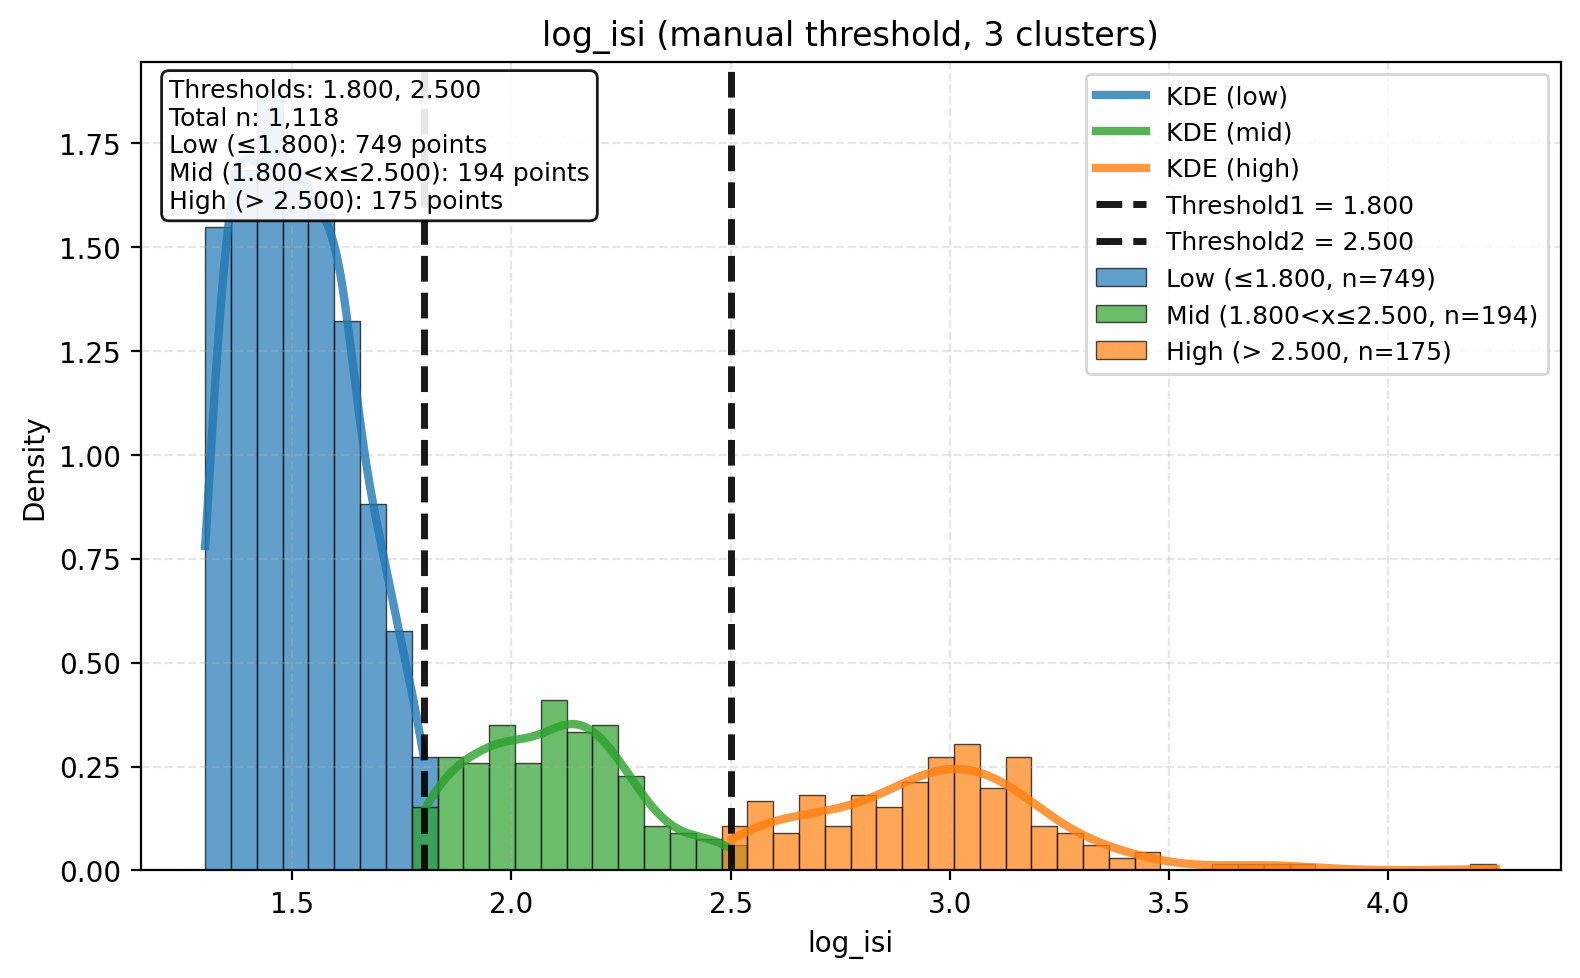

spk_times_ms: Skipped - k_suggest = 1
spk_id: Skipped - k_suggest = 1


In [53]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features.drop(["spk_times_idx"], axis = 1),
    max_k=3,
    suffix="_cluster",ignore_features = "inflection_time",
    plot_each=True,  # set True if you want a quick plot per clustered feature, 
    manual_thresholds={"peak_sharpness":0.6, "exp_lambda": 5, "log_isi":(1.8, 2.5),
        
    }
)







In [54]:
df_features_clust

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_ms,spk_id,peak_amp_cluster,peak_sharpness_cluster,exp_lambda_cluster,log_isi_cluster
0,0.009837,0.32,0.467007,4.066770,0.38,0.776966,1.030429,-0.350241,1.501946,208.480268,0,high,high,low,low
1,0.047172,0.30,0.400746,4.000609,0.36,0.822552,3.802945,-0.521668,1.422054,240.245073,1,high,high,low,low
2,-0.036794,0.34,0.292508,4.075305,0.36,0.623636,5.915424,-0.861539,2.034020,266.672431,2,high,high,high,mid
3,0.508333,0.32,0.288763,4.554854,0.38,0.882994,10.000000,-0.618316,1.597268,374.820695,3,high,high,high,low
4,0.242062,0.32,0.671918,4.696013,0.36,0.867873,6.667226,-0.435759,2.159420,414.381770,4,high,high,high,mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1116,0.078585,0.30,0.326825,1.944270,0.32,0.381207,0.000018,-0.056124,3.809923,227745.772080,1114,low,low,low,high
1117,0.012062,0.26,0.512724,1.945625,0.26,0.412176,0.000022,-0.021553,3.639914,234201.163981,1115,low,low,low,high
1118,0.156769,0.30,0.425757,2.136809,0.32,0.399556,0.000017,0.129661,4.246379,238565.456212,1116,low,low,low,high
1119,0.148740,0.34,0.467079,2.022752,0.34,0.353169,0.016804,-1.369805,3.694783,256200.580007,1117,low,low,low,high


### CLUSTER REPORTS


===== CLUSTER REPORT: peak_amp_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster

→ 1.5 Average waveforms with visual RMSE


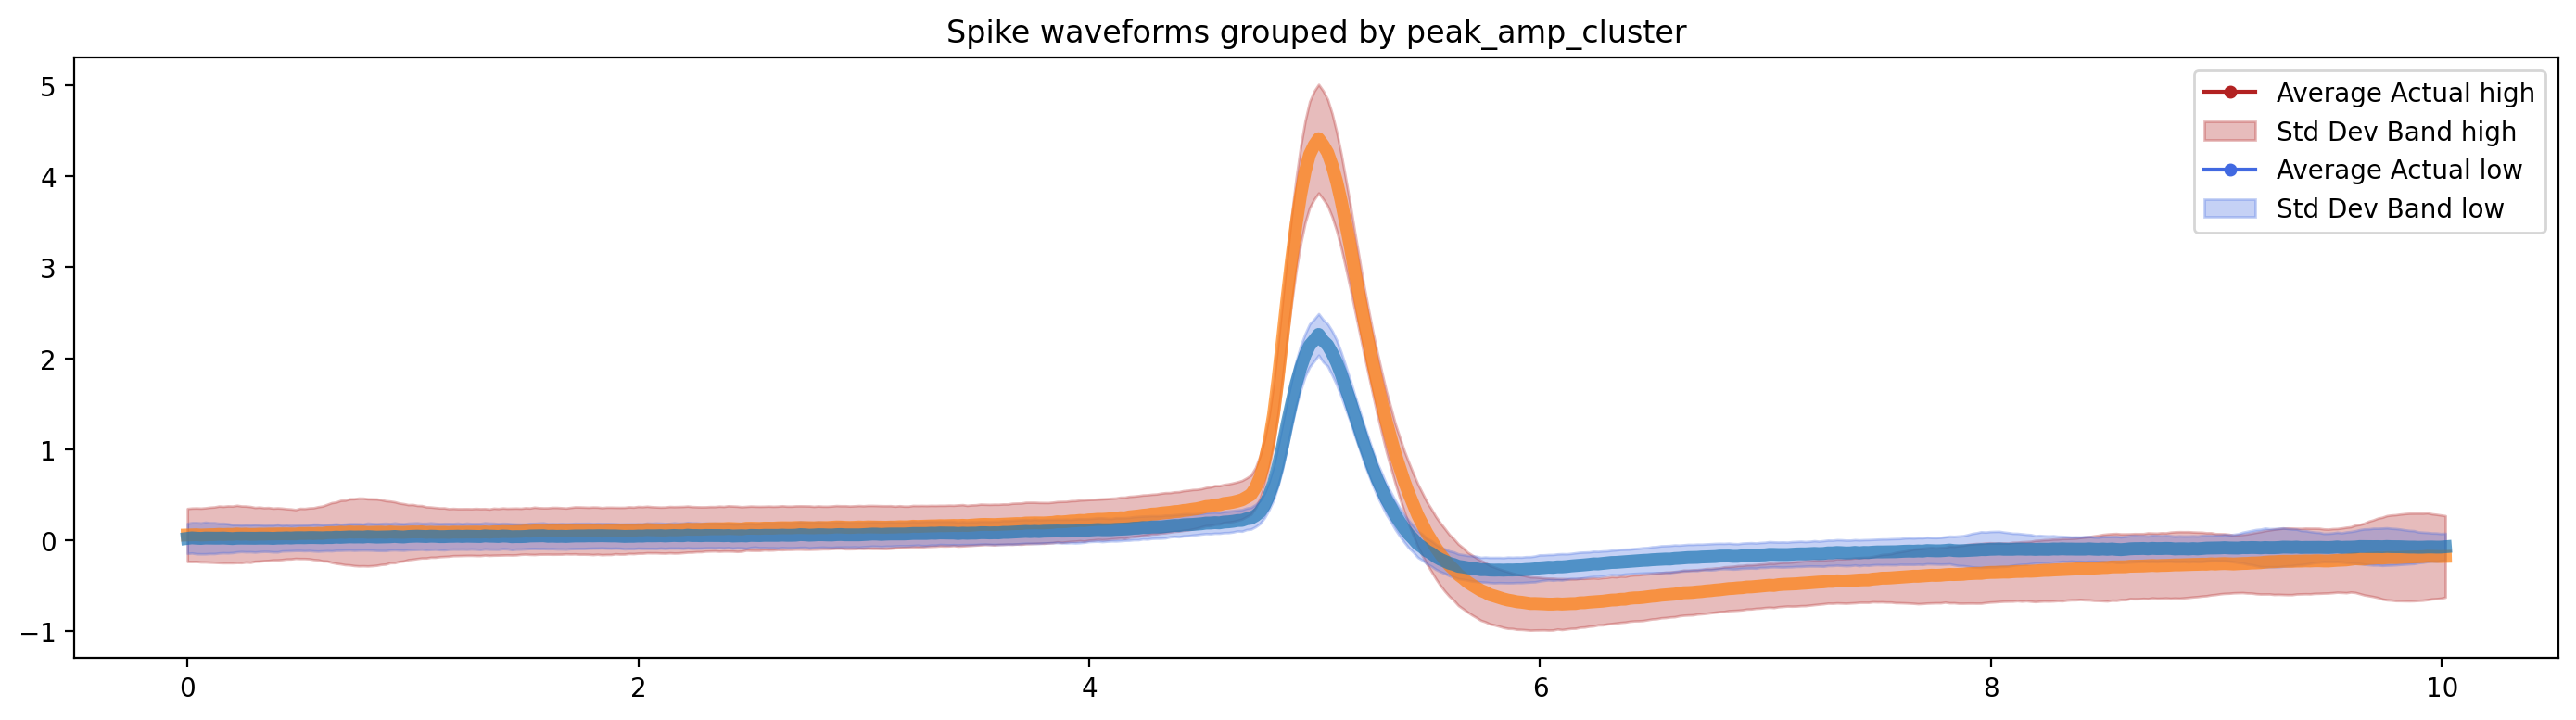

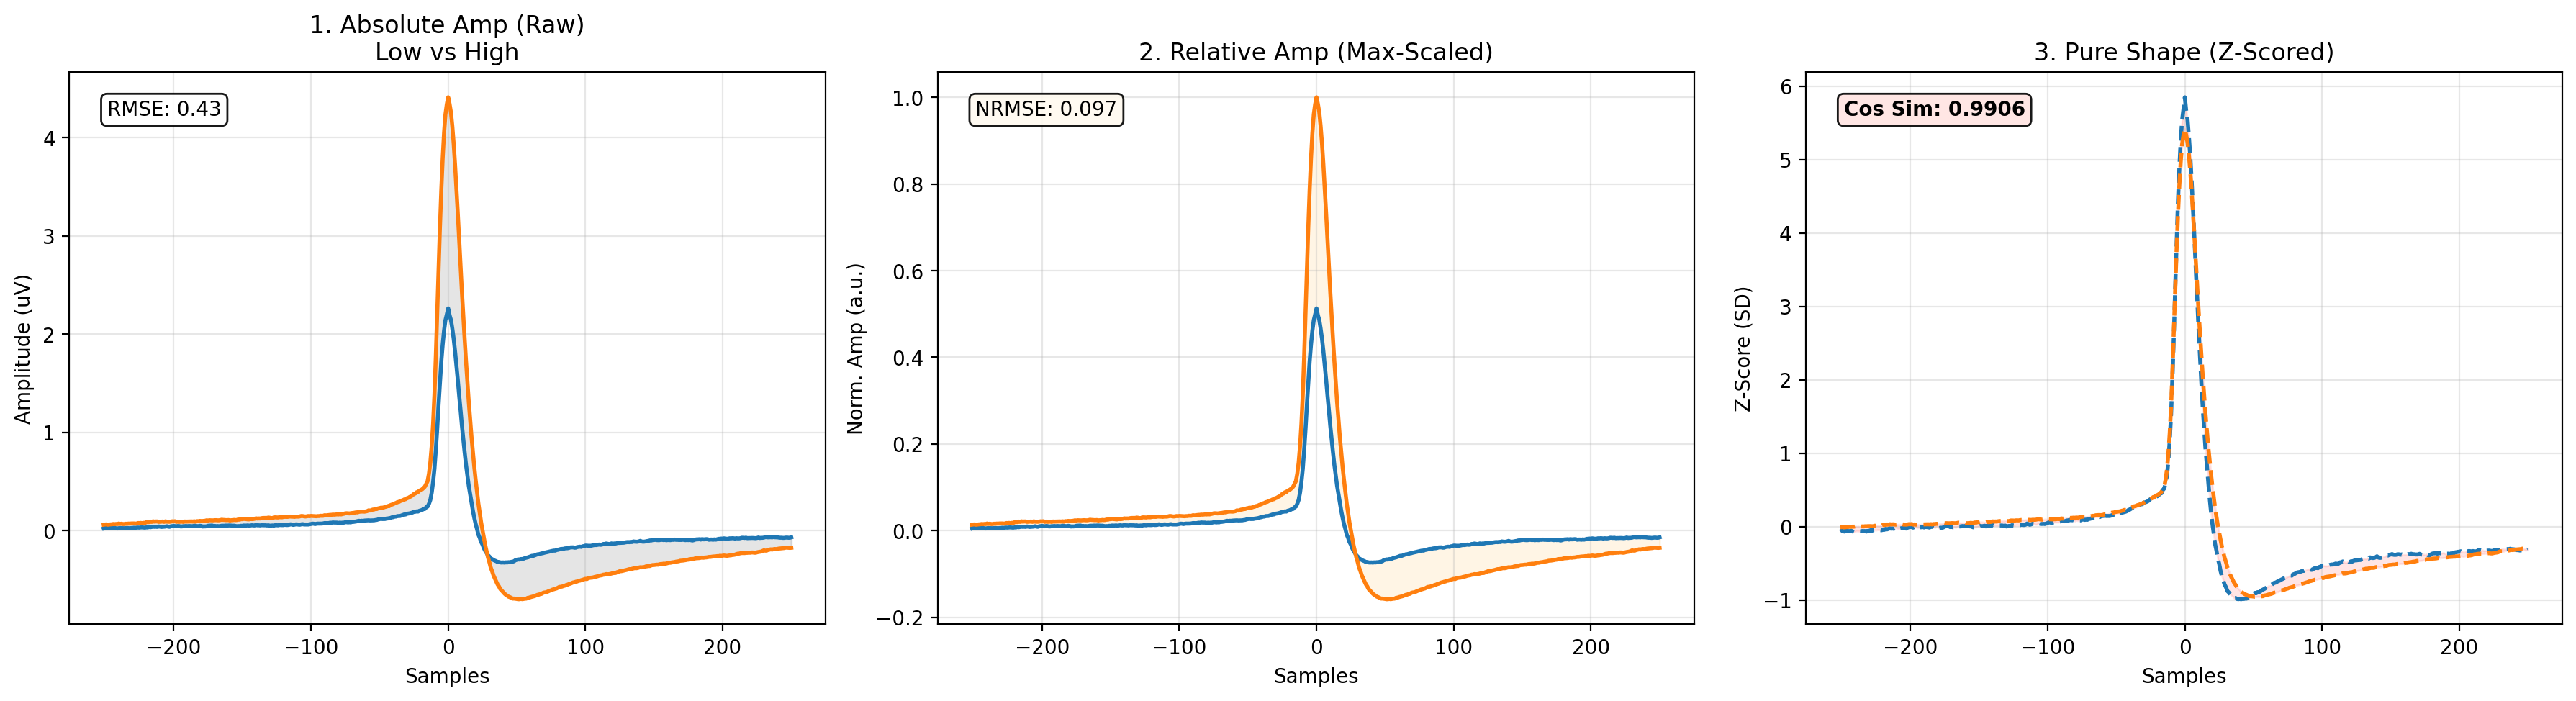


→ 2. Plotting cluster proportions over time


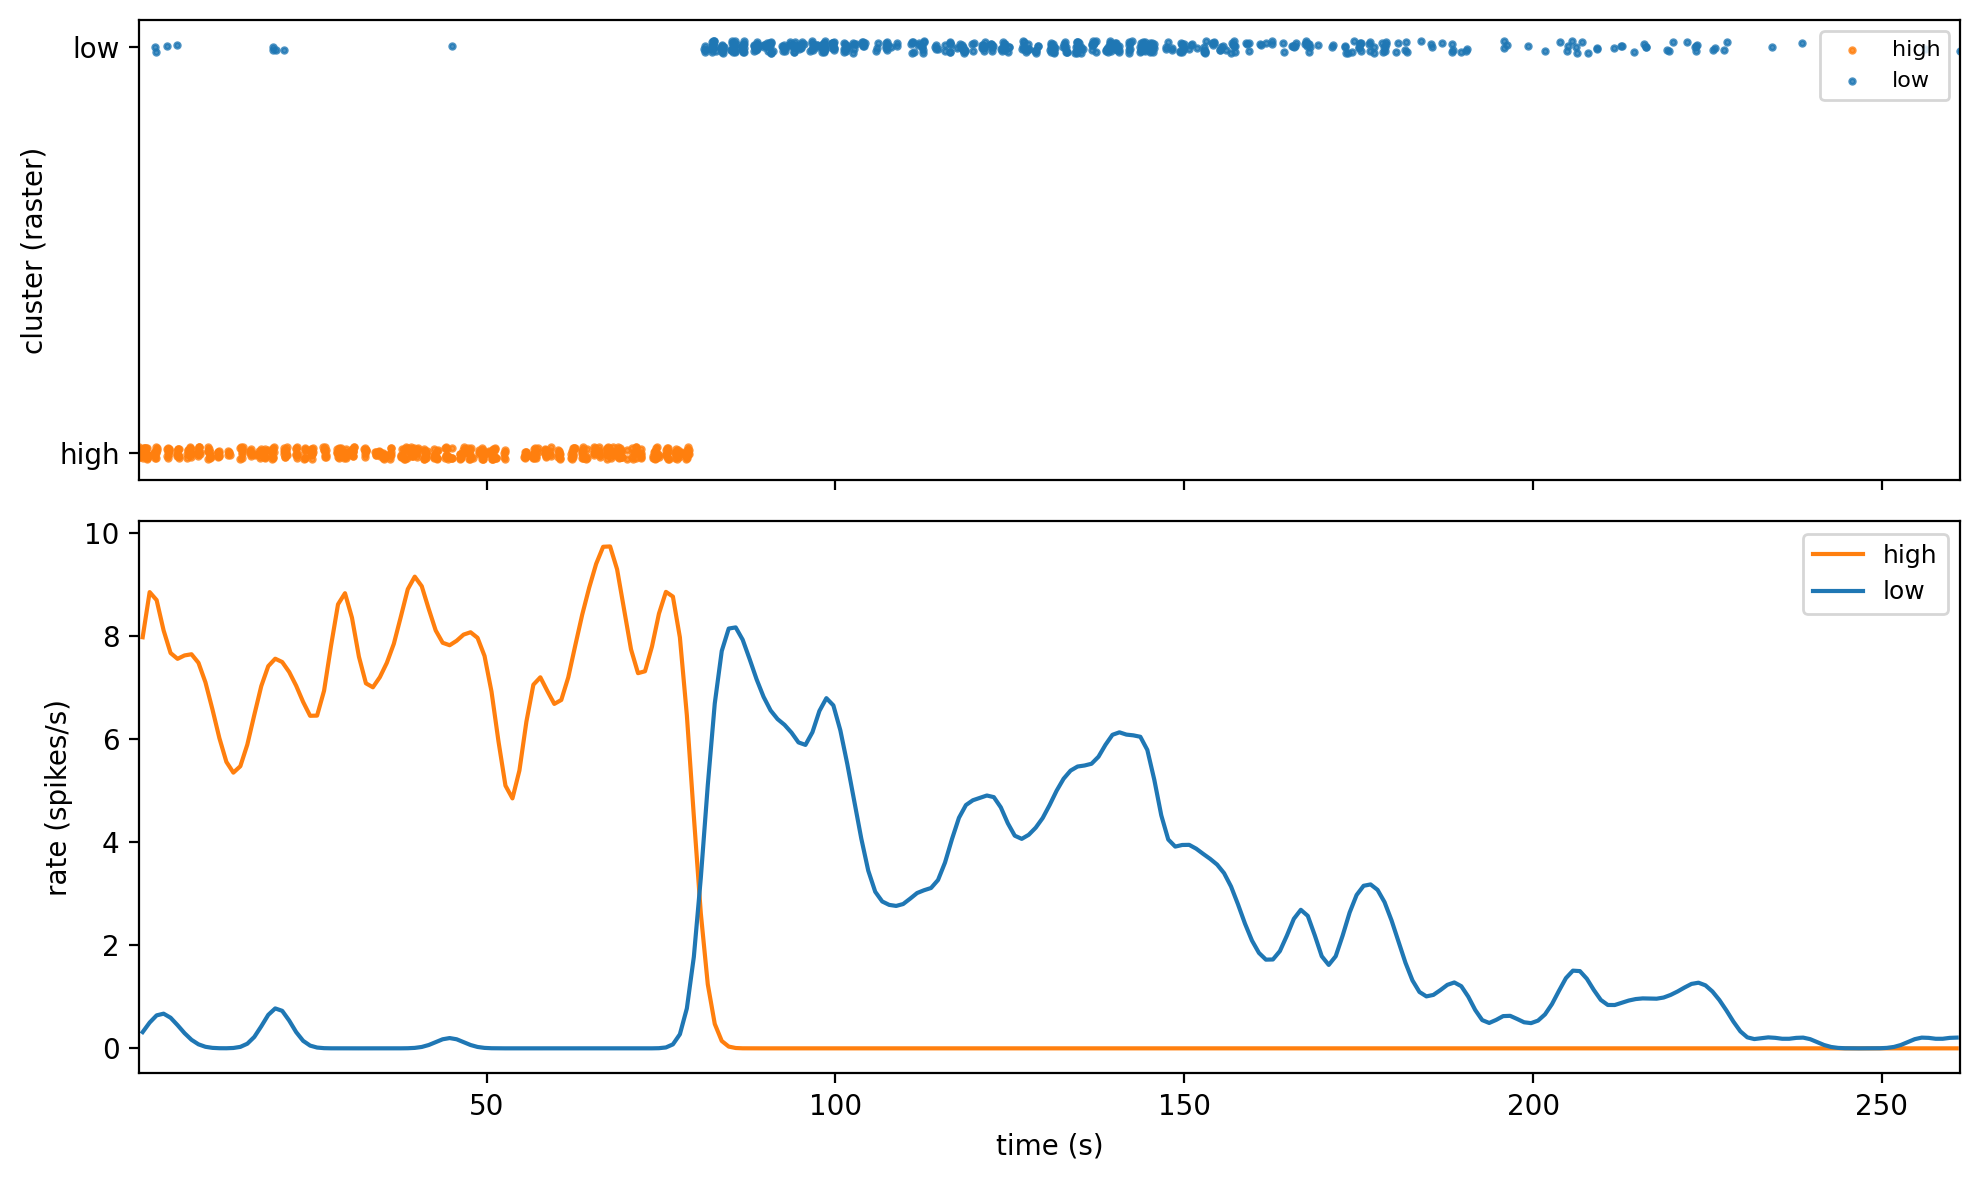


→ 3. Computing cluster transition matrix


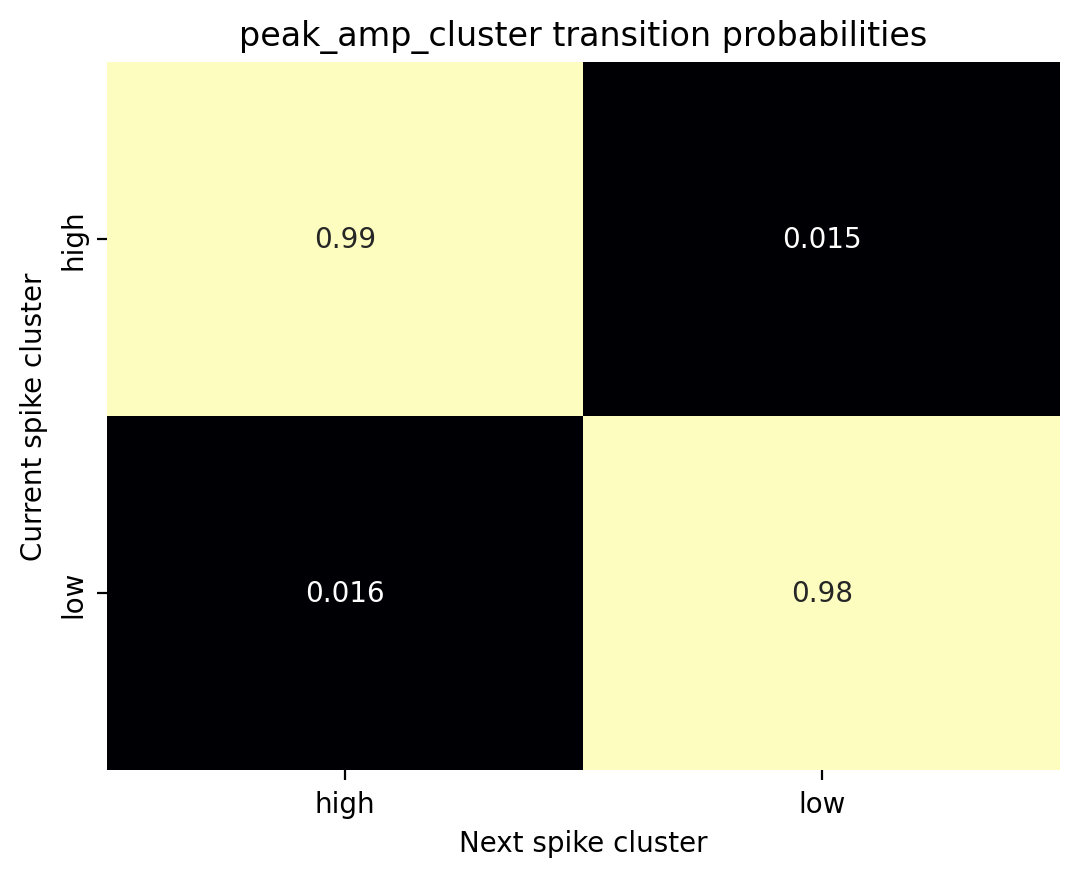


→ 4. Visualizing feature distributions by cluster
Plotting feature distributions by group...
Groups: Low (low), High (high)
Plot order: ('low', 'mid', 'high')
Removing outliers using IQR method (multiplier=3)
Using common normalization for all groups
------------------------------------------------------------
ramp_amp             | Low:   503/503   clean | High:   616/616   clean | 0 outliers removed
inflection_time      | Low:   500/503   clean | High:   616/616   clean | 3 outliers removed
inflection_amp       | Low:   503/503   clean | High:   616/616   clean | 0 outliers removed
peak_amp             | Low:   503/503   clean | High:   612/616   clean | 4 outliers removed
peak_width           | Low:   502/503   clean | High:   616/616   clean | 1 outliers removed
peak_sharpness       | Low:   503/503   clean | High:   616/616   clean | 0 outliers removed
exp_lambda           | Low:   433/503   clean | High:   616/616   clean | 70 outliers removed
exp_const            | Low:   485/5

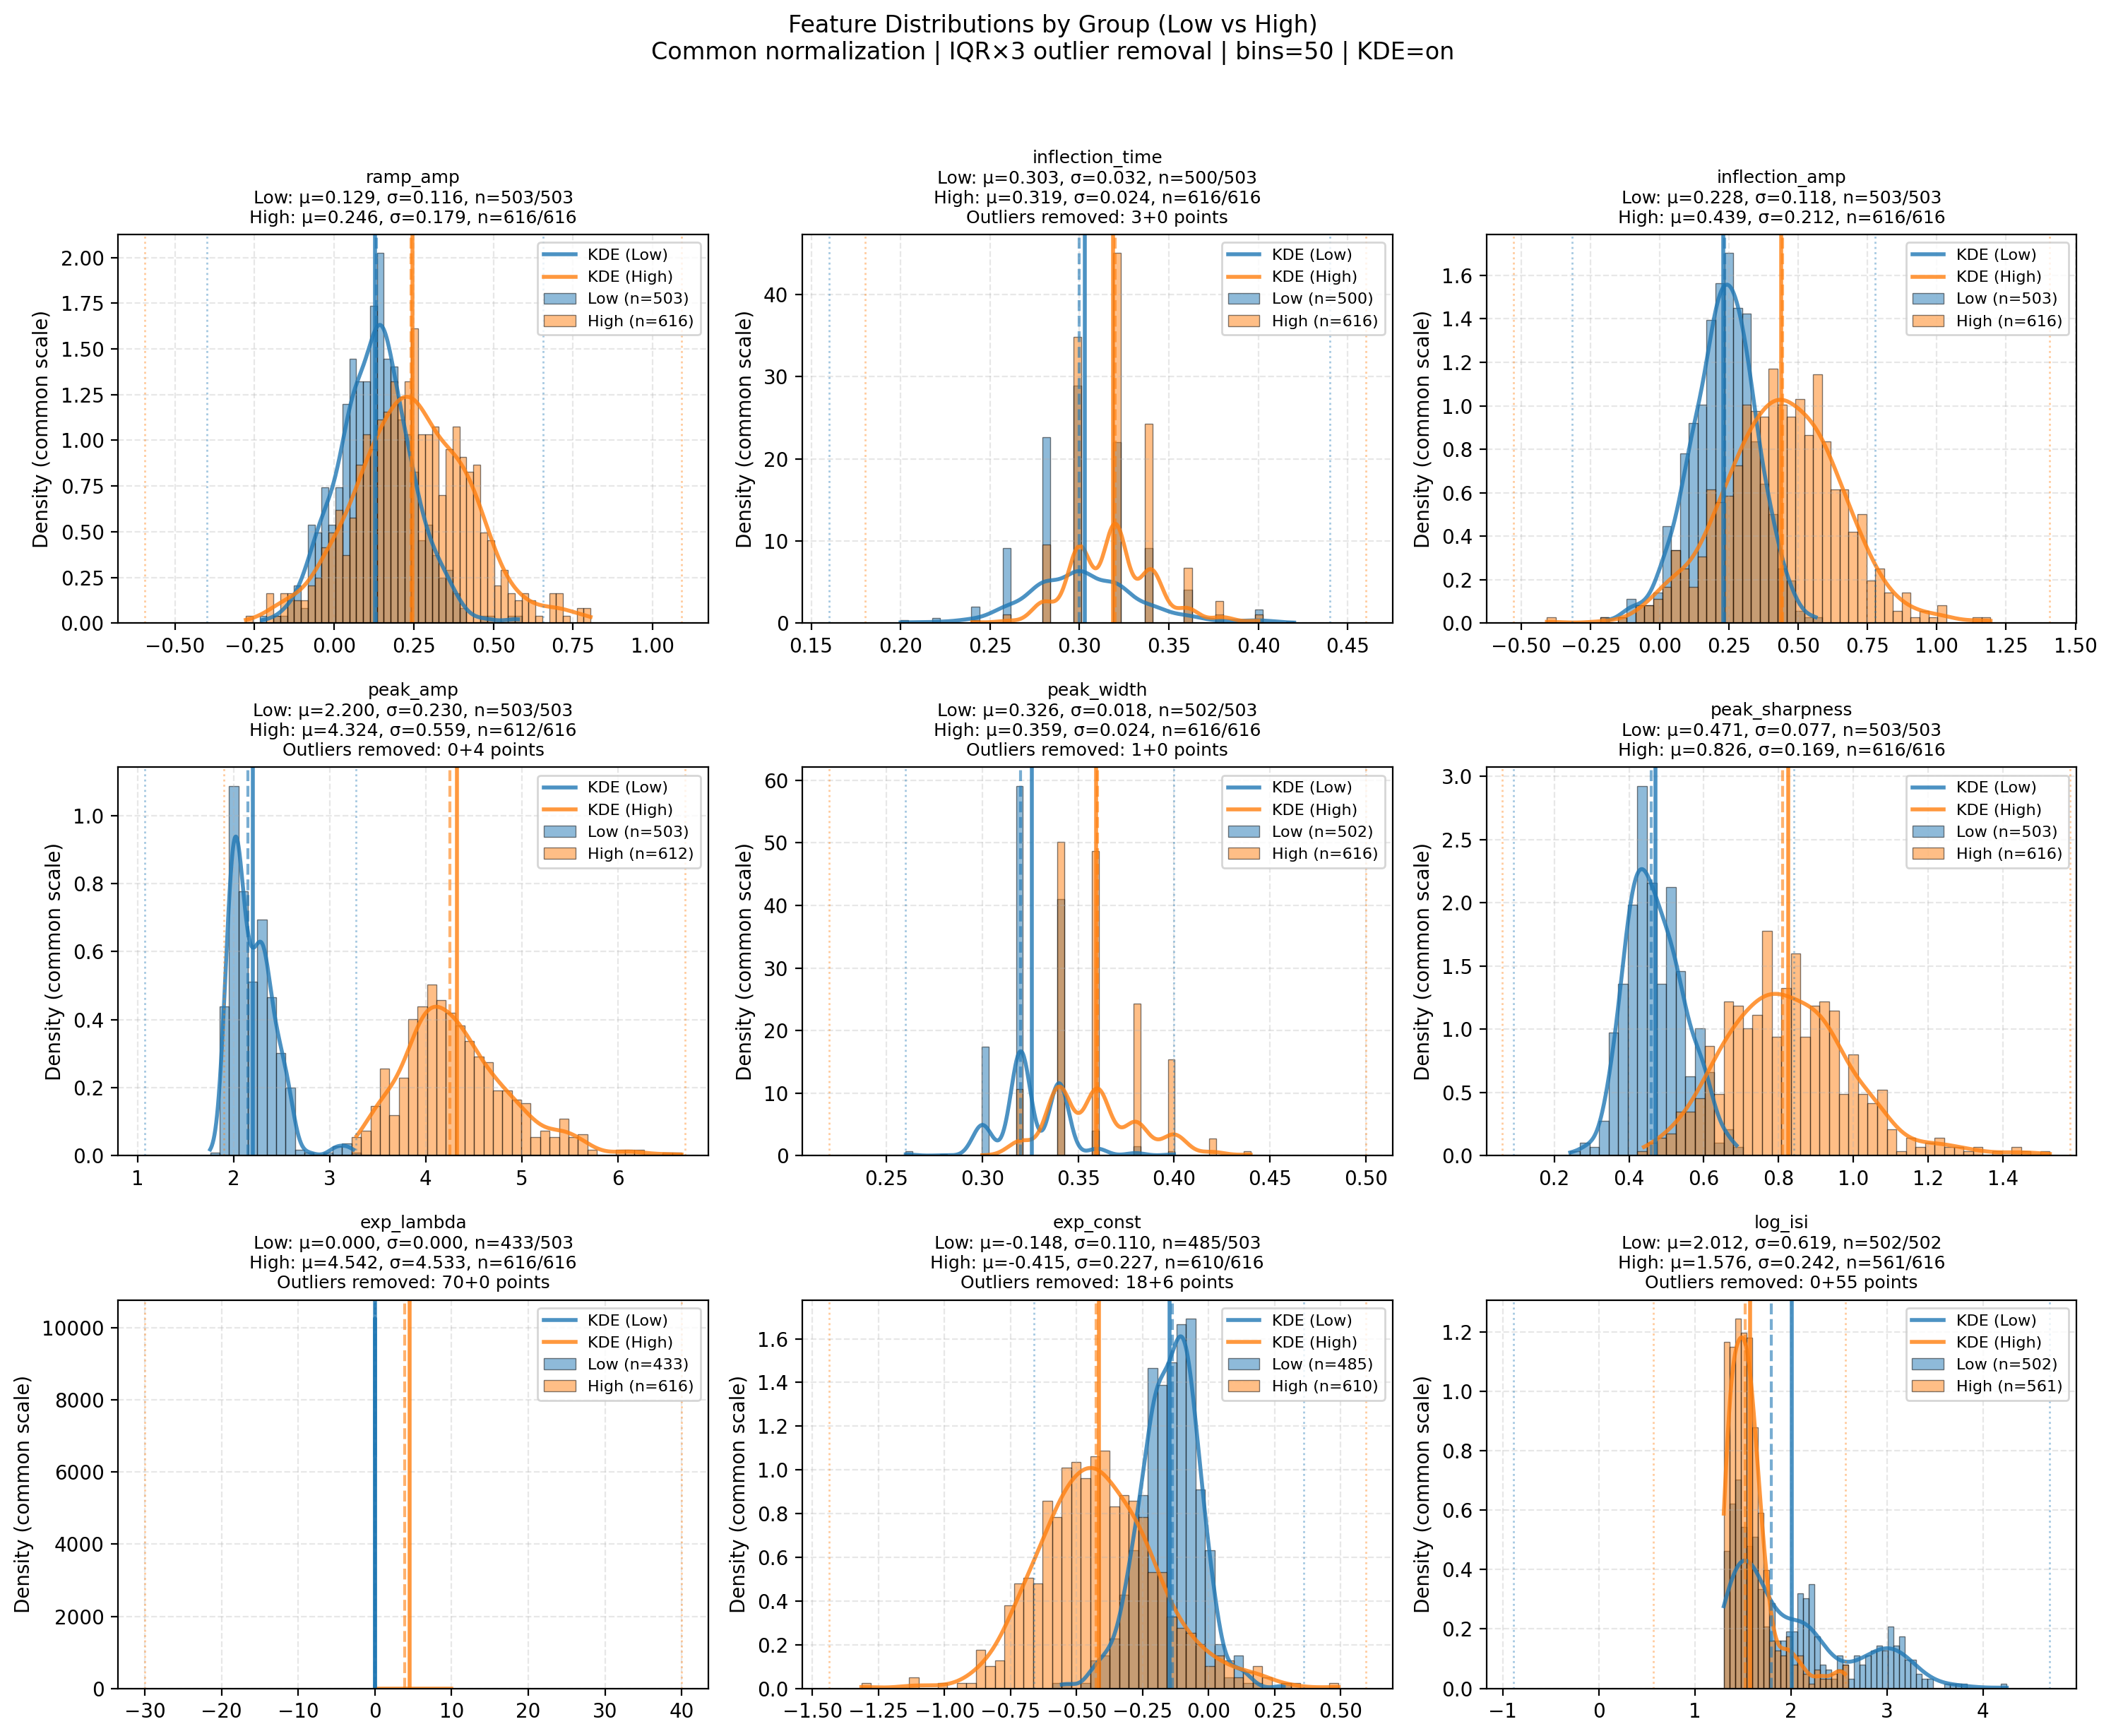

In [ ]:
all_reports = []

# Filter for cluster columns
cluster_cols = [c for c in df_features_clust.columns if c.endswith("_cluster")]

for i, col in enumerate(cluster_cols):
    # 1. Get the DataFrame (1 row for 2 clusters, 3 rows for 3 clusters)
    row_df = plot_full_cluster_report(df_features_clust, sp, col, cluster_group_id=i)
    
    # 2. Assign the cell_id to a new column for ALL rows in row_df
    row_df['cell_id'] = cell_num
    
    all_reports.append(row_df)

# 3. Concatenate 
master_report_df = pd.concat(all_reports, ignore_index=True)

# 4. Reorder to put cell_id first
cols = ['cell_id'] + [c for c in master_report_df.columns if c != 'cell_id']
master_report_df = master_report_df[cols]


In [24]:
master_report_df['waveform_error'][0]

{'Low_vs_High': {'rmse': 0.11678866861847026,
  'nrmse': 0.0315038206608582,
  'cos_sim': 0.9976997066103899}}

#### Export cluster info as pickles 

In [ ]:
#export spike feature df
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/c1_df_features.pkl', 'wb') as file:
    pickle.dump(df_features_clust, file)

#export cluster info df 
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/c1_df_clusters.pkl', 'wb') as file:
    pickle.dump(df_clust_info, file)

## STEP 3: LFP analysis

In [ ]:
# Extract LFP windows for ALL spikes (no condition)
all_spike_extractor = extract_lfp_windows(
    spk_df=df_features_clust,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5,
    condition=None
)

windows_all      = all_spike_extractor["windows"]
t_rel_all        = all_spike_extractor["times_rel_ms"]
spike_times_all  = all_spike_extractor["spike_times_ms"]
next_spk_all     = all_spike_extractor["next_spike_times_ms"]
meta_df_all      = all_spike_extractor["meta_df"]


In [ ]:
"""specparam_by_spike = run_time_resolved_specparam_per_spike(
    lfp_windows=windows_all,
    times_rel_list=t_rel_all,
    next_rel_list=next_spk_all,
    fs=lfp_fs,
    inner_window_sec=0.5,
    freq_range=(4, 90),
    n_freqs=256,
    time_bandwidth=2.0,
    decim_factor=10,
    aperiodic_mode="fixed")"""

In [ ]:
"""
#save as pickle
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c1/specp_epochs.pkl', 'wb') as file:
    pickle.dump(specparam_by_spike, file)"""

In [ ]:
#open pickle
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c1/specp_epochs.pkl', 'rb') as file:
    specparam_by_spike = pickle.load(file)

In [ ]:
specparam_by_spike = trim_edges(specparam_by_spike, edge_sec=0.5)

#### Analyze by group

In [ ]:
groups = build_lfp_groups_from_clusters(df_features_clust
    ,all_spike_extractor)

#### LFP signal

In [ ]:
lfp_heatmaps = plot_window_feature_groups_heatmap(
    groups,
    feature_label="LFP (µV)",
    cmap="viridis",
    time_unit="ms",
)


In [ ]:
gamma_groups = make_specparam_feature_groups(
    specparam_by_spike, groups, feature="band", band="gamma"
)

exp_groups = make_specparam_feature_groups(
    specparam_by_spike, groups, feature="exponent"
)


#### AUC gamma and aperiodic exponents

In [ ]:
_ = plot_window_feature_groups_heatmap(
    gamma_groups,
    feature_label="Gamma AUC",
    cmap="viridis",
    time_unit="s",      # IMPORTANT: specparam times are seconds
    sort_by="next_rel",
)

_ = plot_window_feature_groups_heatmap(
    exp_groups,
    feature_label="Aperiodic exponent",
    cmap="viridis",
    time_unit="s",
    sort_by="next_rel",
)


#### AUC gamma and aperiodic exponents traces

In [ ]:
gamma_pre_spike_win = window_feature_group_traces_ci_delta(
    gamma_groups,
    baseline_window=(-0.5, 1),
    time_unit="s",
)


In [ ]:
_= window_feature_group_traces_ci_delta(
    gamma_groups,
    baseline_window=(-0.5, 1),
    time_unit="s", plot_mode ="per_cluster"
)


In [ ]:
exp_pre_spike_win = window_feature_group_traces_ci_delta(
    exp_groups,
    ylabel="Δ Aperiodic exponent",
    title="Δ Exponent (baseline-corrected, mean ± 95% CI)",
    baseline_window=(-0.5, 1),
)


In [ ]:
_= window_feature_group_traces_ci_delta(
    exp_groups,
    baseline_window=(-0.5, 1),
    time_unit="s", plot_mode ="per_cluster"
)

#### AUC gamma and aperiodic exponents traces and stats for pre spike window

In [ ]:
report_all_gamma =stats_boxplot_from_window_results(
    gamma_pre_spike_win,
    plot_mode="all",
    feature_label="Δ Gamma AUC",
)


In [ ]:
report_all_gamma = stats_boxplot_from_window_results(
    gamma_pre_spike_win,
    plot_mode="per_cluster",
    feature_label="Δ Gamma AUC",
)


In [ ]:
report_all_exp = stats_boxplot_from_window_results(
    exp_pre_spike_win,
    plot_mode="all",
    feature_label="Δ Aperiodic exponent",
)


In [ ]:
report_all_exp = stats_boxplot_from_window_results(
    exp_pre_spike_win,
    plot_mode="per_cluster",
    feature_label="Δ Aperiodic exponent",
)
